<p align="center">
<a href="https://colab.research.google.com/github/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_05.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://kaggle.com/kernels/welcome?src=https://github.com/md-ryhan-uddin/ai-lab-experiments/blob/main/experiment_05.ipynb">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle" height="20"/>
</a>
</p>

## **Experiment 05:** Implementation and Performance Evaluation of Unsupervised Learning and Dimensionality Reduction Algorithms (PCA, K-Means, Hierarchical Clustering, and DBSCAN)

**Course:** ICE 4111: Artificial Intelligence Lab  
**Program:** Bachelor of Science in Information and Communication Engineering (BSc in ICE)  
**Instructor:** Md. Ryhan Uddin

**Student Name:** ______________________________  
**Student ID:** ______________________________  
**Section/Batch:** ______________________________  
**Date of Submission:** ______________________________  


### **Quick Overview**

In this lab you will apply **Principal Component Analysis (PCA)** to compress a high-dimensional dataset into two dimensions, then cluster the standardized data with **K-Means**, **Agglomerative (Hierarchical) Clustering**, and **DBSCAN**. You will evaluate the resulting clusters using internal metrics (Silhouette Score and Davies-Bouldin Index) and visualize every result in PCA space so the algorithms can be compared side by side.

### **Learning Objectives**

After completing this experiment, students will be able to:

- Apply PCA to reduce a high-dimensional feature space to two dimensions and interpret explained variance.
- Train K-Means, Agglomerative Clustering, and DBSCAN on the same standardized dataset.
- Select the number of clusters using the elbow method and a dendrogram, and select DBSCAN's `eps` using a k-distance plot.
- Evaluate clustering quality using the Silhouette Score and Davies-Bouldin Index.
- Visualize and compare cluster assignments in reduced (PCA) space.
- Explain the strengths, weaknesses, and typical use cases of each unsupervised method.


## **Theory**

### Introduction

Unsupervised learning finds structure in data without using known labels. Clustering algorithms group similar samples together, while dimensionality reduction techniques compress data into fewer dimensions while retaining as much structure as possible. PCA is one of the most important linear dimensionality reduction techniques because it finds orthogonal directions of maximum variance. K-Means partitions data into a fixed number of spherical clusters, hierarchical clustering builds a tree of nested clusters, and DBSCAN groups together points that are densely packed while marking sparse points as noise.

### Mathematical Background

Given a centered data matrix $X \in \mathbb{R}^{n \times d}$, PCA computes the covariance matrix

$$\Sigma = \frac{1}{n-1} X^T X$$

and finds its eigenvectors. The eigenvectors associated with the largest eigenvalues define the principal components, and projecting $X$ onto the top $k$ components gives the reduced representation $X_{\text{pca}} = XW_k$.

K-Means minimizes the within-cluster sum of squared distances:

$$J = \sum_{i=1}^{n} \left\| x_i - \mu_{c_i} \right\|^2$$

where $\mu_{c_i}$ is the centroid of the cluster assigned to sample $x_i$.

DBSCAN groups points based on a neighborhood radius $\varepsilon$ and a minimum number of samples `min_samples`; a point is a **core point** if at least `min_samples` points lie within $\varepsilon$ of it, and clusters are formed by chaining together density-connected core points.

For evaluating cluster quality without ground-truth labels, the **Silhouette Score** for a sample $i$ is

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where $a(i)$ is the mean intra-cluster distance and $b(i)$ is the mean distance to the nearest other cluster.

### Important Concepts

The general unsupervised workflow followed in this lab is:

1. Standardize the features so that no single feature dominates due to scale.
2. Reduce dimensionality with PCA for visualization (and optionally for modeling).
3. Run a clustering algorithm on the standardized data.
4. Judge the resulting structure using internal validation indices.

Two internal metrics are used throughout this notebook:

- **Silhouette Score:** ranges from $-1$ to $1$. Higher values indicate samples are well matched to their own cluster and poorly matched to neighboring clusters.
- **Davies-Bouldin Index:** measures the average similarity between each cluster and its most similar counterpart. Lower values indicate better, more compact and well-separated clusters.

Hierarchical clustering additionally produces a **dendrogram**, a tree diagram showing the order in which clusters are merged, which is useful for deciding how many clusters to keep. DBSCAN does not require the number of clusters to be specified in advance and can discover clusters of arbitrary shape, but it requires careful tuning of `eps` and `min_samples`.

### Advantages and Applications

**Advantages**

- PCA is fast, interpretable, and removes redundancy caused by correlated features.
- K-Means is simple and efficient, scaling well to large datasets.
- Hierarchical clustering gives a multi-level view of the data structure via the dendrogram.
- DBSCAN can discover clusters of arbitrary shape and automatically labels outliers as noise.

**Applications**

These methods are widely used in customer segmentation, image compression, anomaly and fraud detection, gene expression analysis, and exploratory data analysis before supervised modeling.

```mermaid
flowchart LR
    A[Raw Features] --> B[Standardization]
    B --> C[PCA]
    C --> D[K-Means]
    C --> E[Hierarchical Clustering]
    C --> F[DBSCAN]
    D --> G[Cluster Validation Metrics]
    E --> G
    F --> G
    G --> H[Visualization in PCA Space]
```


## **Required Software and Libraries**

Install or prepare the following before starting the lab:

- Python 3.12 or later
- Jupyter Notebook, JupyterLab, VS Code, or Google Colab
- NumPy
- Pandas
- Matplotlib
- SciPy, used here for building the dendrogram
- Scikit-learn

### Starter Check

Run the first code cell (library imports and setup). If it prints `Setup complete. You can start the experiment.`, your environment is ready.

## **Dataset Description**

This experiment uses the **Wine dataset**, a classic multivariate benchmark available directly from Scikit-learn. It has enough numeric features and clear underlying group structure to make PCA and clustering results easy to interpret and visualize.

- **Features:** 13 numeric chemical measurements of wine samples (e.g. alcohol, malic acid, color intensity).
- **Target labels:** three wine cultivars, used **only as a visual reference** — clustering itself never sees these labels.
- **Source:** `sklearn.datasets.load_wine`.
- **Reason for selection:** moderate dimensionality, no missing values, and clusters that separate well after standardization and PCA.

## **Experimental Procedure**

Follow the steps below in order:

1. Load the Wine dataset and standardize all features using `StandardScaler`.
2. Apply PCA and inspect the explained variance ratio of the first two components.
3. Use the elbow method to select the number of clusters for K-Means, then train it.
4. Build a dendrogram, then train Agglomerative (Hierarchical) Clustering with the same number of clusters.
5. Use a k-distance plot to select `eps` for DBSCAN, then train it.
6. Compute the Silhouette Score and Davies-Bouldin Index for every algorithm.
7. Visualize all cluster assignments in PCA space and compare the models.

### Student Checkpoint

Before moving to the discussion section, make sure you can answer:

- Why must the data be standardized before PCA and clustering, given that the Wine features are on very different scales?
- Which algorithm produced the highest Silhouette Score, and does its cluster shape in the PCA scatter plot explain why?
- How many points did DBSCAN label as noise, and what does that indicate about the density of the Wine dataset in this feature space?


## **Source Code**

Run the following cells one by one. Read the output after each cell and add comments in your own words where instructed by your teacher.

**Tip:** Do not only run the notebook. Try changing the number of clusters in K-Means, the linkage method in hierarchical clustering, or `eps`/`min_samples` in DBSCAN, and observe what changes.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [28]:
# Load the Wine dataset

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

print("Shape:", X.shape)
print("Class counts:\n", y.value_counts().sort_index())
print("Target names:", wine.target_names)

Shape: (178, 13)
Class counts:
 target
0    59
1    71
2    48
Name: count, dtype: int64
Target names: ['class_0' 'class_1' 'class_2']


In [29]:
# Standardize the features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Std after scaling (should be ~1) :", np.round(X_scaled.std(axis=0)[:5], 3))

Mean after scaling (should be ~0): [-0. -0. -0. -0. -0.]
Std after scaling (should be ~1) : [1. 1. 1. 1. 1.]


In [30]:
# Apply PCA for 2D visualization

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.36198848 0.1920749 ]
Total explained variance: 0.5540633835693527


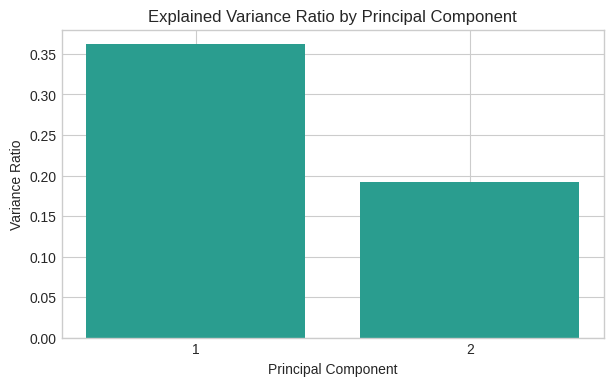

In [31]:
# Explained Variance by Principal Component

plt.figure(figsize=(7, 4))

plt.bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    color="#2a9d8f"
)

plt.title("Explained Variance Ratio by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.xticks([1, 2])

plt.show()

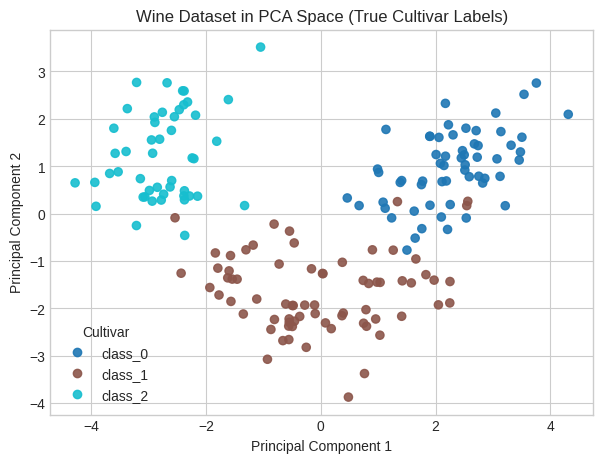

In [32]:
# PCA Projection Colored by True Wine Cultivar (reference only)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="tab10",
    s=35,
    alpha=0.9
)

plt.title("Wine Dataset in PCA Space (True Cultivar Labels)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=list(wine.target_names),
    title="Cultivar"
)

plt.show()

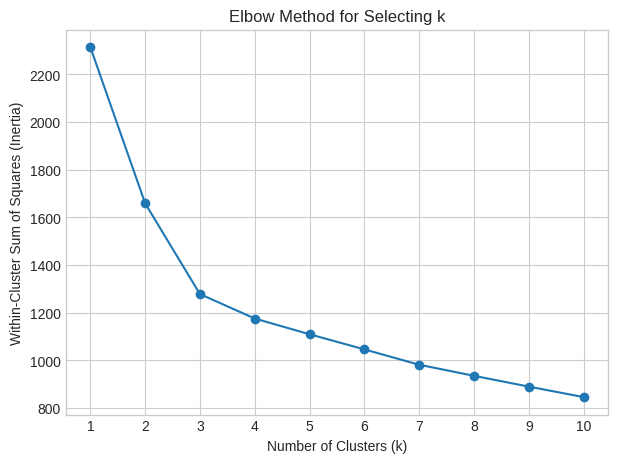

In [33]:
# Elbow Method for K-Means

from sklearn.cluster import KMeans

k_values = range(1, 11)
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))

plt.plot(k_values, wcss, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Selecting k")
plt.xticks(k_values)

plt.show()

In [34]:
# Train K-Means Clustering

from sklearn.cluster import KMeans

# Initialize the model
kmeans_model = KMeans(
    n_clusters=14,       # Chosen from the elbow plot and known cultivar count
    random_state=42,
    n_init=10
)

# Fit the model
kmeans_model.fit(X_scaled)

print("K-Means model trained successfully!")

K-Means model trained successfully!


In [35]:
# Display Model Information

print("Number of Clusters :", kmeans_model.n_clusters)
print("Inertia             :", round(kmeans_model.inertia_, 2))
print("Iterations Run       :", kmeans_model.n_iter_)

Number of Clusters : 14
Inertia             : 742.67
Iterations Run       : 7


In [36]:
# Cluster Assignments

labels_kmeans = kmeans_model.labels_

kmeans_counts = pd.Series(labels_kmeans).value_counts().sort_index()
print("Cluster sizes:\n", kmeans_counts)

Cluster sizes:
 0     11
1     20
2     15
3     20
4     16
5     16
6     16
7      9
8     13
9      8
10    10
11     3
12     7
13    14
Name: count, dtype: int64


In [37]:
# Evaluate K-Means

silhouette_kmeans = silhouette_score(X_scaled, labels_kmeans)
db_kmeans = davies_bouldin_score(X_scaled, labels_kmeans)

print(f"Silhouette Score      : {silhouette_kmeans:.4f}")
print(f"Davies-Bouldin Index  : {db_kmeans:.4f}")

Silhouette Score      : 0.1270
Davies-Bouldin Index  : 1.6506


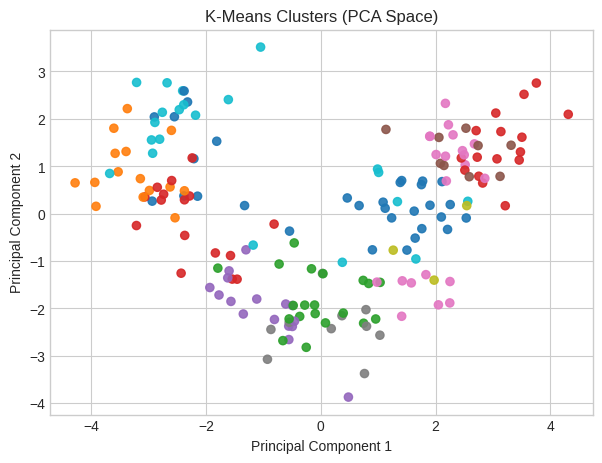

In [38]:
# Visualize K-Means Clusters in PCA Space

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    cmap="tab10",
    s=35,
    alpha=0.9
)

plt.title("K-Means Clusters (PCA Space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

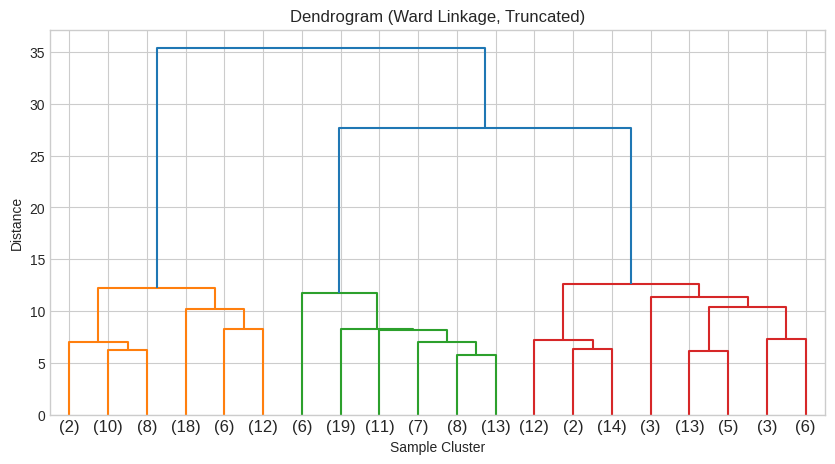

In [39]:
# Dendrogram for Hierarchical Clustering

plt.figure(figsize=(10, 5))

merge_matrix = linkage(X_scaled, method="ward")

dendrogram(merge_matrix, truncate_mode="lastp", p=20)

plt.title("Dendrogram (Ward Linkage, Truncated)")
plt.xlabel("Sample Cluster")
plt.ylabel("Distance")

plt.show()

In [40]:
# Train Agglomerative (Hierarchical) Clustering

from sklearn.cluster import AgglomerativeClustering

# Initialize the model
hier_model = AgglomerativeClustering(
    n_clusters=3,        # Chosen to match the dendrogram cut
    linkage="ward"
)

# Fit and predict in one step
labels_hier = hier_model.fit_predict(X_scaled)

print("Hierarchical Clustering model trained successfully!")

Hierarchical Clustering model trained successfully!


In [41]:
# Display Model Information

print("Number of Clusters :", hier_model.n_clusters_)
print("Linkage Method       :", hier_model.linkage)

hier_counts = pd.Series(labels_hier).value_counts().sort_index()
print("Cluster sizes:\n", hier_counts)

Number of Clusters : 3
Linkage Method       : ward
Cluster sizes:
 0    58
1    56
2    64
Name: count, dtype: int64


In [42]:
# Evaluate Hierarchical Clustering

silhouette_hier = silhouette_score(X_scaled, labels_hier)
db_hier = davies_bouldin_score(X_scaled, labels_hier)

print(f"Silhouette Score      : {silhouette_hier:.4f}")
print(f"Davies-Bouldin Index  : {db_hier:.4f}")

Silhouette Score      : 0.2774
Davies-Bouldin Index  : 1.4186


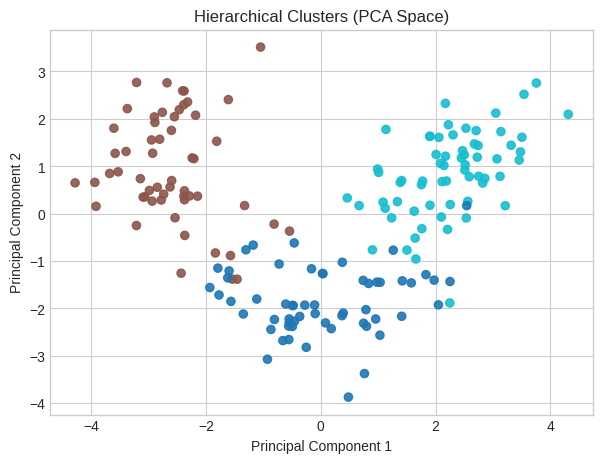

In [43]:
# Visualize Hierarchical Clusters in PCA Space

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_hier,
    cmap="tab10",
    s=35,
    alpha=0.9
)

plt.title("Hierarchical Clusters (PCA Space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

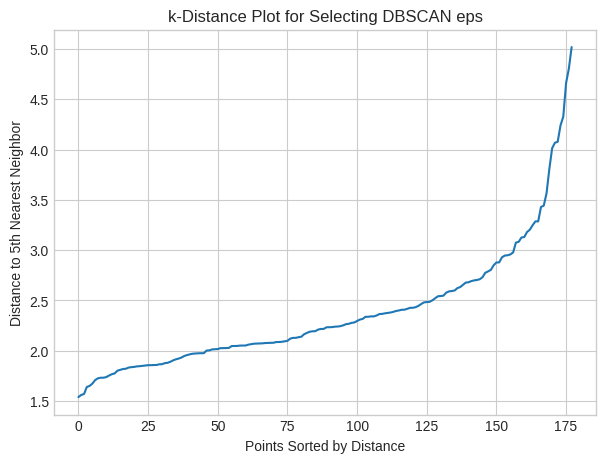

In [44]:
# k-Distance Plot for Selecting DBSCAN's eps

from sklearn.neighbors import NearestNeighbors

k = 5  # equal to min_samples used below
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)

distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(7, 5))

plt.plot(k_distances)

plt.xlabel("Points Sorted by Distance")
plt.ylabel(f"Distance to {k}th Nearest Neighbor")
plt.title("k-Distance Plot for Selecting DBSCAN eps")

plt.show()

In [45]:
# Train DBSCAN

from sklearn.cluster import DBSCAN

# Initialize the model
dbscan_model = DBSCAN(
    eps=2.2,          # Chosen from the "elbow" of the k-distance plot
    min_samples=5
)

# Fit and predict in one step
labels_dbscan = dbscan_model.fit_predict(X_scaled)

print("DBSCAN model trained successfully!")

DBSCAN model trained successfully!


In [46]:
# Display Model Information

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = int((labels_dbscan == -1).sum())

print("Epsilon (eps)        :", dbscan_model.eps)
print("Min Samples          :", dbscan_model.min_samples)
print("Clusters Found        :", n_clusters_dbscan)
print("Noise Points          :", n_noise)

Epsilon (eps)        : 2.2
Min Samples          : 5
Clusters Found        : 2
Noise Points          : 55


In [47]:
# Evaluate DBSCAN

# Exclude noise points (-1) before computing internal metrics
valid_mask = labels_dbscan != -1

if n_clusters_dbscan > 1 and valid_mask.sum() > n_clusters_dbscan:
    silhouette_dbscan = silhouette_score(X_scaled[valid_mask], labels_dbscan[valid_mask])
    db_dbscan = davies_bouldin_score(X_scaled[valid_mask], labels_dbscan[valid_mask])
else:
    silhouette_dbscan = np.nan
    db_dbscan = np.nan

print(f"Silhouette Score      : {silhouette_dbscan:.4f}")
print(f"Davies-Bouldin Index  : {db_dbscan:.4f}")

Silhouette Score      : 0.3480
Davies-Bouldin Index  : 1.1244


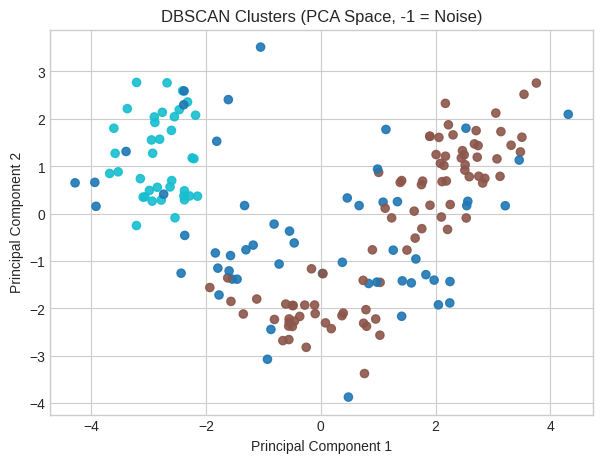

In [48]:
# Visualize DBSCAN Clusters in PCA Space

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_dbscan,
    cmap="tab10",
    s=35,
    alpha=0.9
)

plt.title("DBSCAN Clusters (PCA Space, -1 = Noise)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [49]:
# Compare All Models

comparison = [
    ["K-Means", kmeans_model.n_clusters, silhouette_kmeans, db_kmeans],
    ["Hierarchical", hier_model.n_clusters_, silhouette_hier, db_hier],
    ["DBSCAN", n_clusters_dbscan, silhouette_dbscan, db_dbscan],
]

comparison_df = pd.DataFrame(
    comparison,
    columns=["Algorithm", "Clusters Found", "Silhouette Score", "Davies-Bouldin Index"]
)

comparison_df = comparison_df.round(4)

comparison_df

,Algorithm,Clusters Found,Silhouette Score,Davies-Bouldin Index
0,K-Means,14,0.1270,1.6506
1,Hierarchical,3,0.2774,1.4186
2,DBSCAN,2,0.3480,1.1244


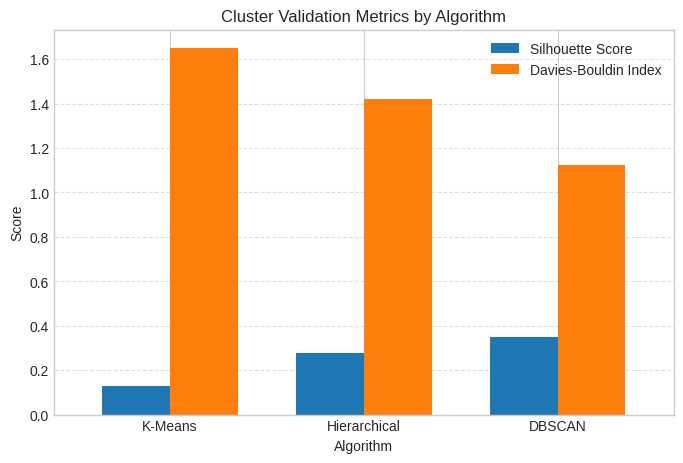

In [50]:
# Grouped Bar Chart of Cluster Validation Metrics

comparison_df.set_index("Algorithm")[
    ["Silhouette Score", "Davies-Bouldin Index"]
].plot(
    kind="bar",
    figsize=(8, 5),
    width=0.7
)

plt.title("Cluster Validation Metrics by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(loc="upper right")
plt.show()

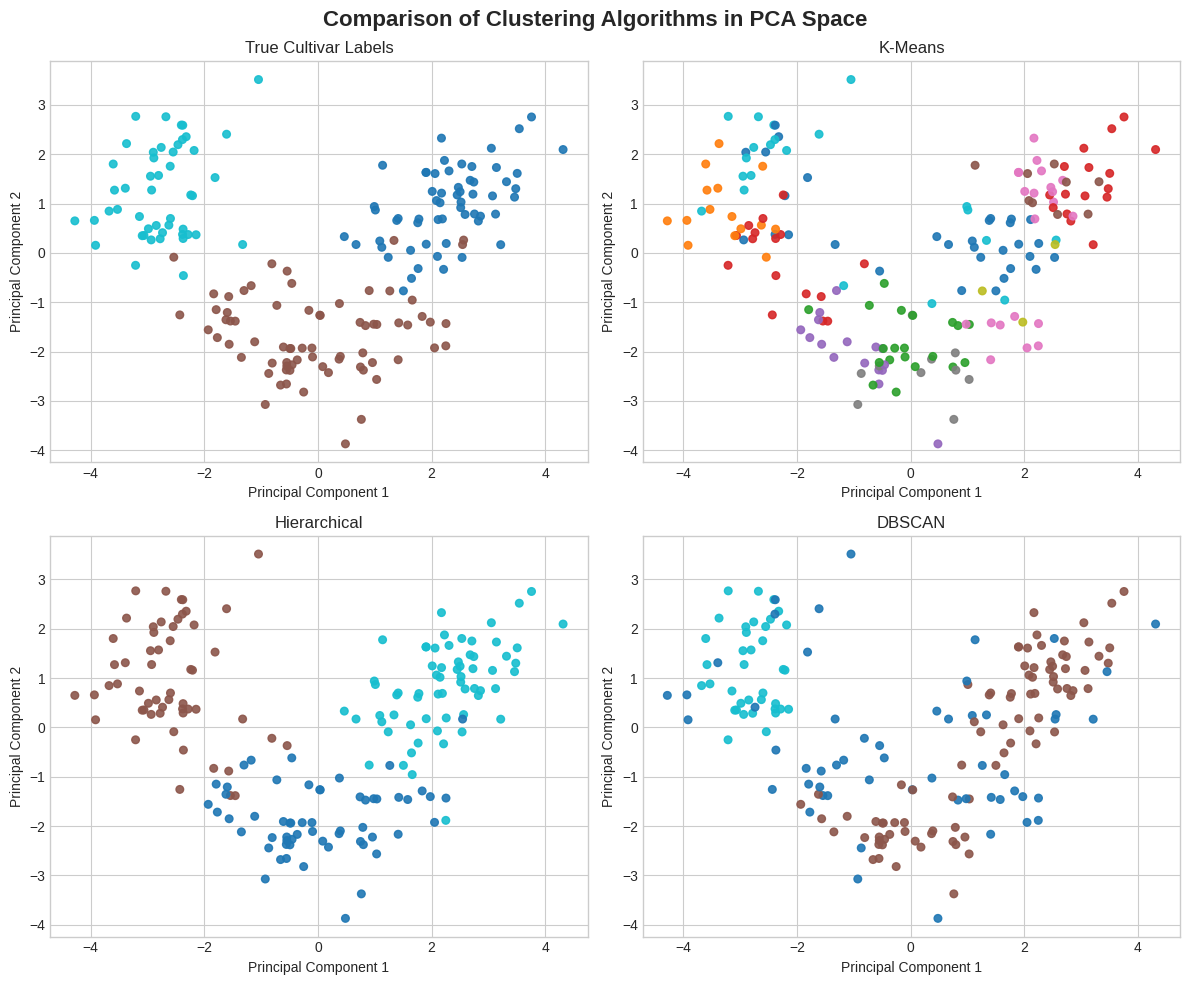

In [51]:
# Side-by-Side Cluster Comparison in PCA Space

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

panels = {
    "True Cultivar Labels": y,
    "K-Means": labels_kmeans,
    "Hierarchical": labels_hier,
    "DBSCAN": labels_dbscan,
}

for ax, (name, labels) in zip(axes, panels.items()):

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="tab10",
        s=30,
        alpha=0.9
    )

    ax.set_title(name)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

plt.suptitle(
    "Comparison of Clustering Algorithms in PCA Space",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## **Expected Output**

After running all cells, the notebook should display:

- Wine dataset shape, class counts, and target names.
- Confirmation that features were standardized to zero mean and unit variance.
- PCA explained variance ratio and a bar chart of variance by component.
- An elbow plot for choosing K-Means's `k`, a dendrogram for hierarchical clustering, and a k-distance plot for DBSCAN's `eps`.
- Cluster sizes, Silhouette Score, and Davies-Bouldin Index for each of the three algorithms.
- PCA-space scatter plots for each algorithm individually, plus a combined 2x2 comparison grid.
- A metric comparison table and grouped bar chart summarizing all three algorithms.

You should include the important outputs in your lab report and briefly explain what each output means.

## **Discussion**

K-Means performs well on the Wine dataset because the standardized clusters are roughly spherical and balanced, and it directly optimizes within-cluster variance. Hierarchical clustering produces very similar groupings and additionally reveals the merge order through the dendrogram, though it is more expensive on larger datasets. DBSCAN does not require the number of clusters to be fixed in advance and can flag outliers as noise, but its performance is sensitive to the choice of `eps` and `min_samples`, and it may merge or split clusters differently from the other two methods depending on local density.

## **Viva Questions**

1. **Q:** What is the purpose of PCA?  
   **A:** To reduce dimensionality while preserving as much variance as possible.

2. **Q:** Why should data be standardized before PCA and clustering?  
   **A:** Because PCA and distance-based clustering algorithms are sensitive to feature scale.

3. **Q:** What objective does K-Means minimize?  
   **A:** The within-cluster sum of squared distances between samples and their assigned centroid.

4. **Q:** How was the number of clusters chosen for K-Means?  
   **A:** Using the elbow method, by finding the point where inertia stops decreasing sharply.

5. **Q:** What does a dendrogram show?  
   **A:** The order and distance at which clusters are merged in hierarchical clustering.

6. **Q:** What do the two parameters of DBSCAN, `eps` and `min_samples`, control?  
   **A:** `eps` is the neighborhood radius and `min_samples` is the minimum number of points required to form a dense region (a core point).

7. **Q:** What does a label of `-1` mean in DBSCAN's output?  
   **A:** The point is classified as noise; it does not belong to any dense cluster.

8. **Q:** What is the Silhouette Score, and what range of values indicates good clustering?  
   **A:** It measures how similar a sample is to its own cluster compared with other clusters; values closer to 1 indicate better clustering.

9. **Q:** Why is a lower Davies-Bouldin Index considered better?  
   **A:** It indicates clusters that are more compact internally and better separated from each other.

10. **Q:** Why is clustering called unsupervised learning?  
    **A:** Because it groups data based on patterns in the features alone, without using labeled outputs during training.

## **Exercises**

Complete the following tasks after running the notebook:

1. Change the number of clusters in K-Means (e.g. `k = 2` or `k = 4`) and observe how the Silhouette Score and Davies-Bouldin Index change.
2. Try a different linkage strategy for hierarchical clustering (e.g. `average` or `complete`) and compare the resulting dendrogram and metrics.
3. Tune DBSCAN's `eps` and `min_samples` and record how many points are labeled as noise at each setting.
4. Re-run PCA with three components and compute the cumulative explained variance.
5. Apply the same full pipeline (standardize, PCA, K-Means, hierarchical, DBSCAN) to the Iris dataset and compare the results with the Wine dataset.

## **Lab Report Submission Checklist**

Before submitting, confirm that your report includes:

- Completed cover information.
- Objective and theory summary in your own words.
- All important code outputs, including the metric comparison table.
- The elbow plot, dendrogram, k-distance plot, and the combined PCA comparison grid.
- Short discussion of which algorithm performed best and why.
- Answers to assigned viva questions.
- Completed exercises.

**Reminder:** A good lab report should not only show screenshots. It should explain what the outputs mean.
